In [1]:
! pip install corner --upgrade

In [2]:
! pip install dynesty --upgrade

   ---------------------------------------- 0.0/108.2 kB ? eta -:--:--
   --- ------------------------------------ 10.2/108.2 kB ? eta -:--:--
   ---------------------------------------- 108.2/108.2 kB 2.1 MB/s eta 0:00:00


In [3]:
# Execute this cell
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm, uniform
import corner
import dynesty
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
from IPython.display import display, Math

In [4]:
file_path = "data_files/transient.npy"

In [5]:
mydata = np.load(file_path)
print(mydata.shape)

(100, 3)


In [6]:
time = np.array(mydata[:, 0])
flux = np.array(mydata[:, 1])
flux_err = np.array(mydata[:, 2])

In [7]:
# only for vectorial data
# pars = [b, t0, A, a] correct order
def model(data, pars):
    result = np.zeros(len(data))
    for i in range(len(data)):
        if data[i]<pars[1]:
            result[i] = pars[0]
        else:
            result[i] = pars[0]+pars[2]*np.exp(-pars[3]*(data[i]-pars[1]))
    return result

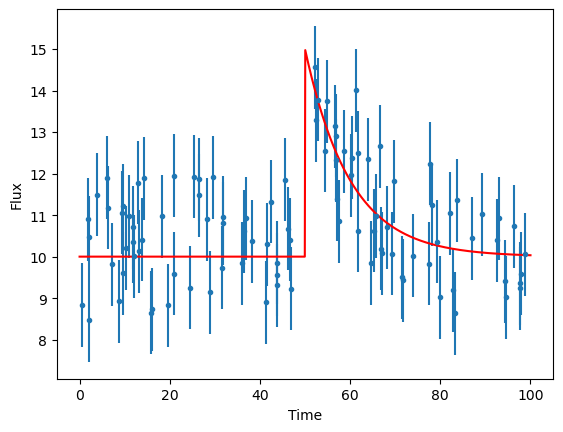

In [8]:
# calculation by hand of initial guesses
asse_x = np.linspace(0, 100, 1000)
asse_y = model(asse_x, [10, 50, 5, 0.1])
plt.errorbar(time, flux, yerr=flux_err, linestyle="", marker=".")
plt.plot(asse_x, asse_y, color="red")
plt.xlabel("Time")
plt.ylabel("Flux")
plt.show()

In [9]:
# let's assume gaussian homoscedastic errors
def logLikelihood(pars, x, y, yerr):
    y_model = model(x, pars)
    if np.any(np.isnan(y_model)) or np.any(~np.isfinite(y_model)):
      return -np.inf
    else:
      return -0.5 * np.sum(((y - y_model) / yerr)**2 + np.log(2 * np.pi * yerr**2))

In [10]:
# Be careful with how you transform your parameter space into a unit hypercube for the nested sampling priors
def prior_transform(vec_u):
    prior_b = 0.0 + 50.0 * vec_u[0]           # b ~ Uniform(0, 50)
    prior_t0 = 0.0 + 100.0 * vec_u[1]         # t0 ~ Uniform(0, 100)
    prior_A = 0.0 + 50.0 * vec_u[2]           # A ~ Uniform(0, 50)
    prior_ln_a = -5.0 + 10.0 * vec_u[3]       # ln(a) ~ Uniform(-5, 5)
    prior_a = np.exp(prior_ln_a)              # Convert from ln(a) to a
    return np.array([prior_b, prior_t0, prior_A, prior_a])

In [11]:
# "Static" nested sampling
sampler = dynesty.NestedSampler(logLikelihood, prior_transform, ndim=4, logl_args=(time, flux, flux_err))
sampler.run_nested()
sresults = sampler.results

3276it [00:12, 111.27it/s, bound: 23 | nc: 30 | ncall: 35367 | eff(%):  9.263 | loglstar:   -inf < -179.286 <    inf | logz: -186.196 +/-  0.110 | dlogz: 37.701 >  0.509]   C:\Users\HP\anaconda3\Lib\site-packages\dynesty\bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
3964it [00:27, 20.34it/s, bound: 63 | nc: 97 | ncall: 65166 | eff(%):  6.083 | loglstar:   -inf < -178.432 <    inf | logz: -185.337 +/-  0.108 | dlogz: 35.573 >  0.509]  C:\Users\HP\anaconda3\Lib\site-packages\dynesty\bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uni

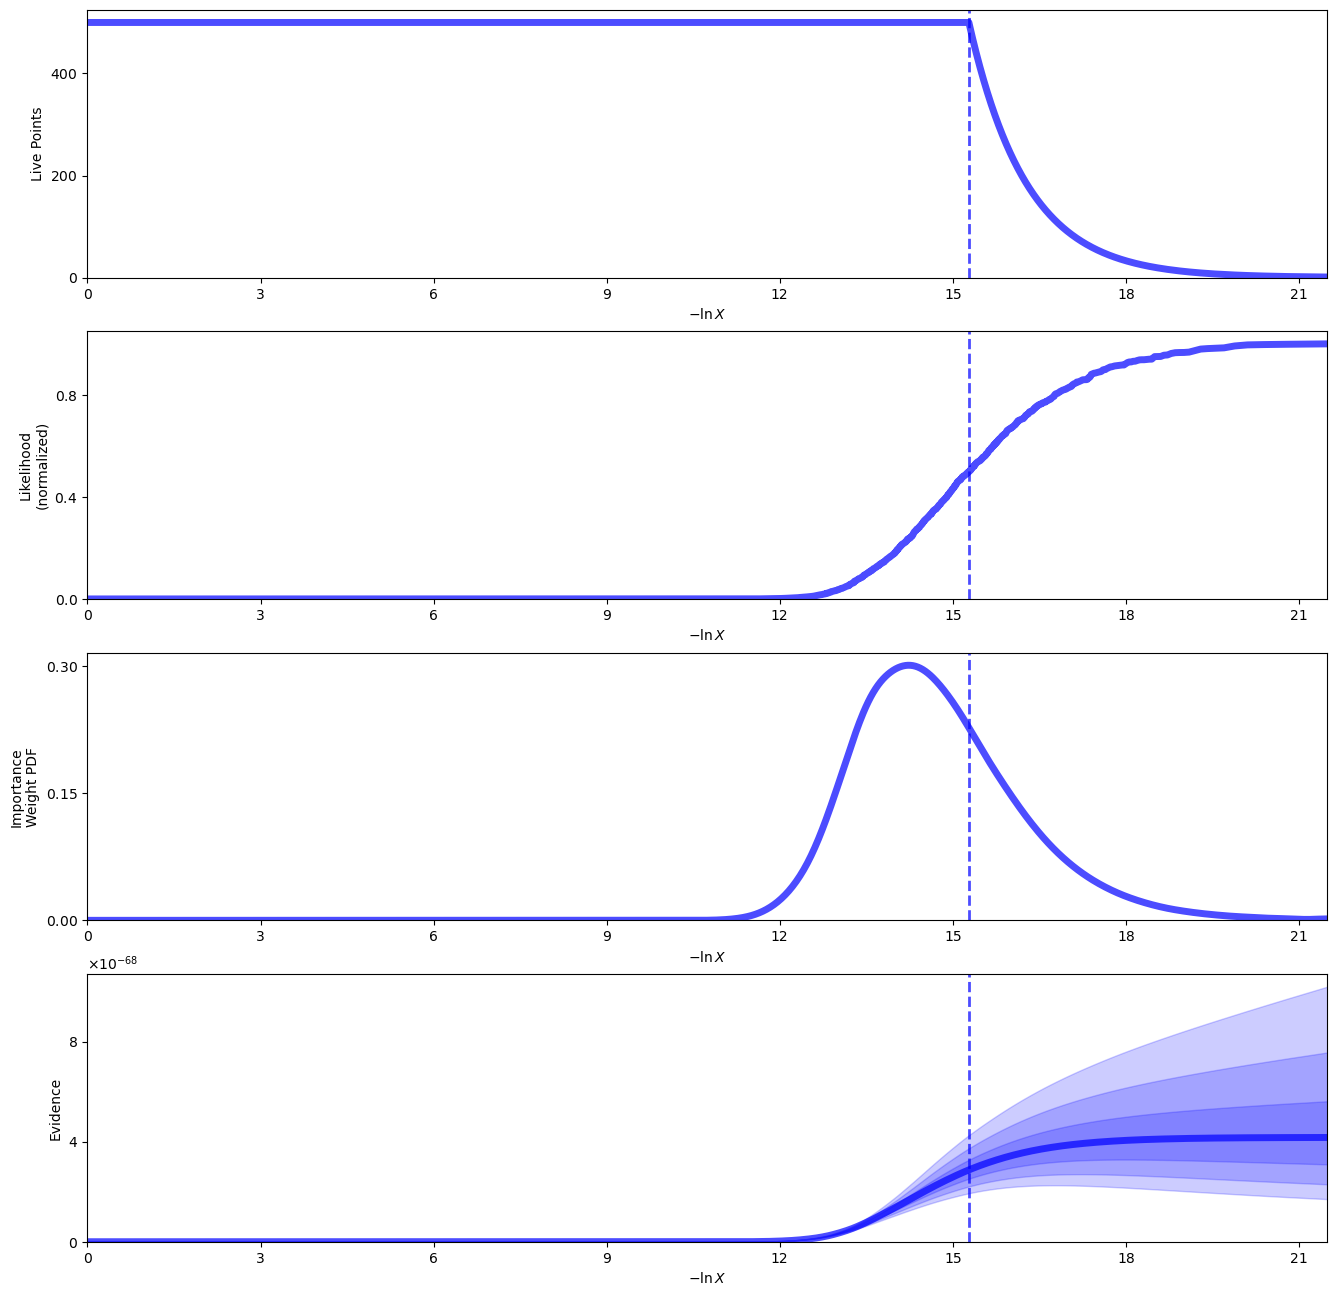

In [12]:
# Plot a summary of the run
rfig, raxes = dyplot.runplot(sresults)

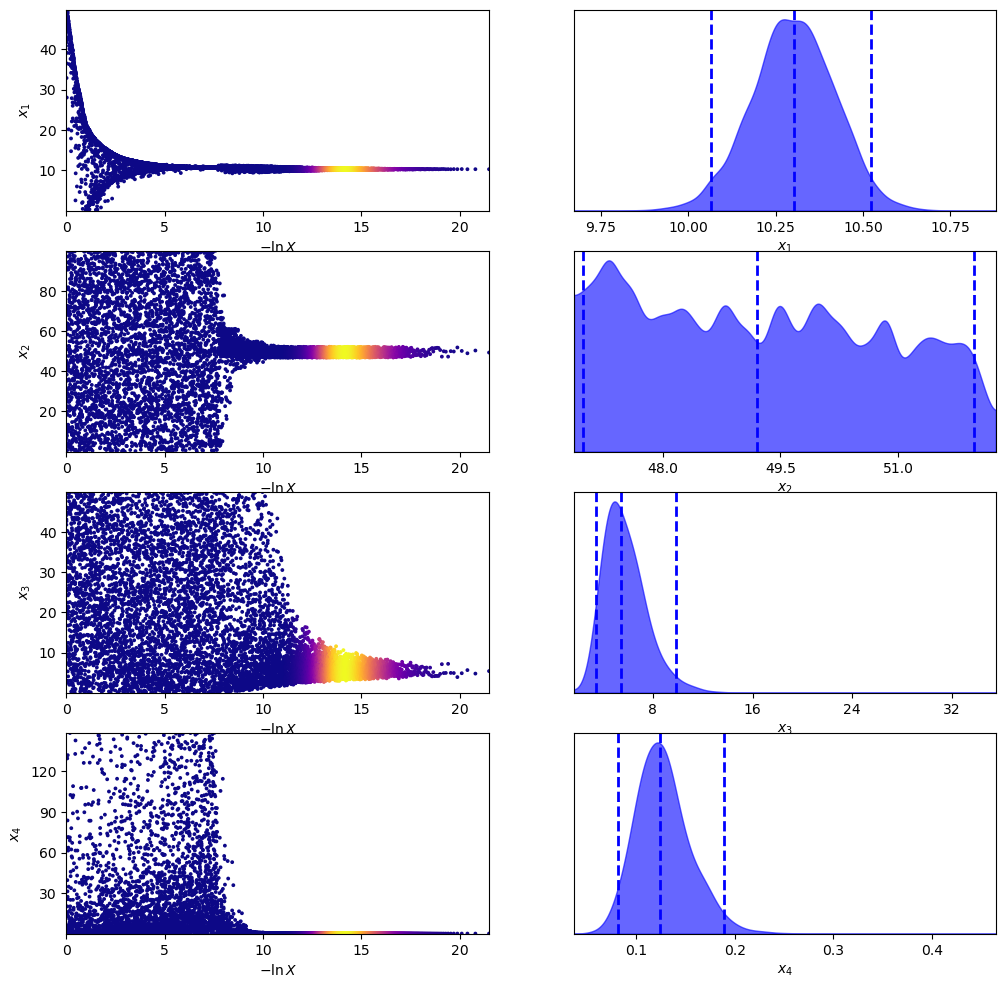

In [13]:
# Plot parameter traces and 1-D marginalized posteriors.
# On the left panels, you'll see that the live points started out scattereed across the prior volume, then move inwards as the sampler climbs the likelihood
tfig, taxes = dyplot.traceplot(sresults)

In [14]:
# Extract sampling results
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights

evidence = sresults.logz[-1] # evidence
print(f"Bayesian evidence: {np.exp(evidence): .3e}")

# Compute quantiles
quantiles = [dyfunc.quantile(samps, [0.05, 0.16, 0.84, 0.95], weights=weights) for samps in samples.T]

# Compute medians
medians = [dyfunc.quantile(samps, 0.5, weights=weights) for samps in samples.T]
medians = np.array(medians).flatten()

print("ROBUST PARAMETERS ESTIMATION (using 90% parameter credible regions):")
print(f"b = {medians[0]: .3f} +{quantiles[0][3]-medians[0]: .3f} -{medians[0]-quantiles[0][0]: .3f}")
print(f"t0 = {medians[1]: .1f} +{quantiles[1][3]-medians[1]: .1f} -{medians[1]-quantiles[1][0]: .1f}")
print(f"A = {medians[2]: .1f} +{quantiles[2][3]-medians[2]: .1f} -{medians[2]-quantiles[2][0]: .1f}")
print(f"a = {medians[3]: .3f} +{quantiles[3][3]-medians[3]: .3f} -{medians[3]-quantiles[3][0]: .3f}")

# Compute weighted mean and covariance
mean, cov = dyfunc.mean_and_cov(samples, weights)
print("MEAN AND STD PARAMETERS ESTIMATION:")
print(f"b = {mean[0]: .2f} +-{np.sqrt(cov[0,0]): .2f}")
print(f"t0 = {mean[1]: .1f} +-{np.sqrt(cov[1,1]): .1f}")
print(f"A = {mean[2]: .1f} +-{np.sqrt(cov[2,2]): .1f}")
print(f"a = {mean[3]: .3f} +-{np.sqrt(cov[3,3]): .3f}")

Bayesian evidence:  4.167e-68
ROBUST PARAMETERS ESTIMATION (using 90% parameter credible regions):
b =  10.302 + 0.185 - 0.200
t0 =  49.2 + 2.6 - 2.1
A =  5.4 + 3.5 - 1.8
a =  0.124 + 0.052 - 0.037
MEAN AND STD PARAMETERS ESTIMATION:
b =  10.30 +- 0.12
t0 =  49.3 +- 1.5
A =  5.7 +- 1.7
a =  0.127 +- 0.028


In [15]:
# dynesty can postprocess results to produce equally weighted samples.
# This is useful if you then want to used them in another package (for instance corner) that cannot deal with weights.
# Resample weighted samples
samples_equal = dyfunc.resample_equal(samples, weights)

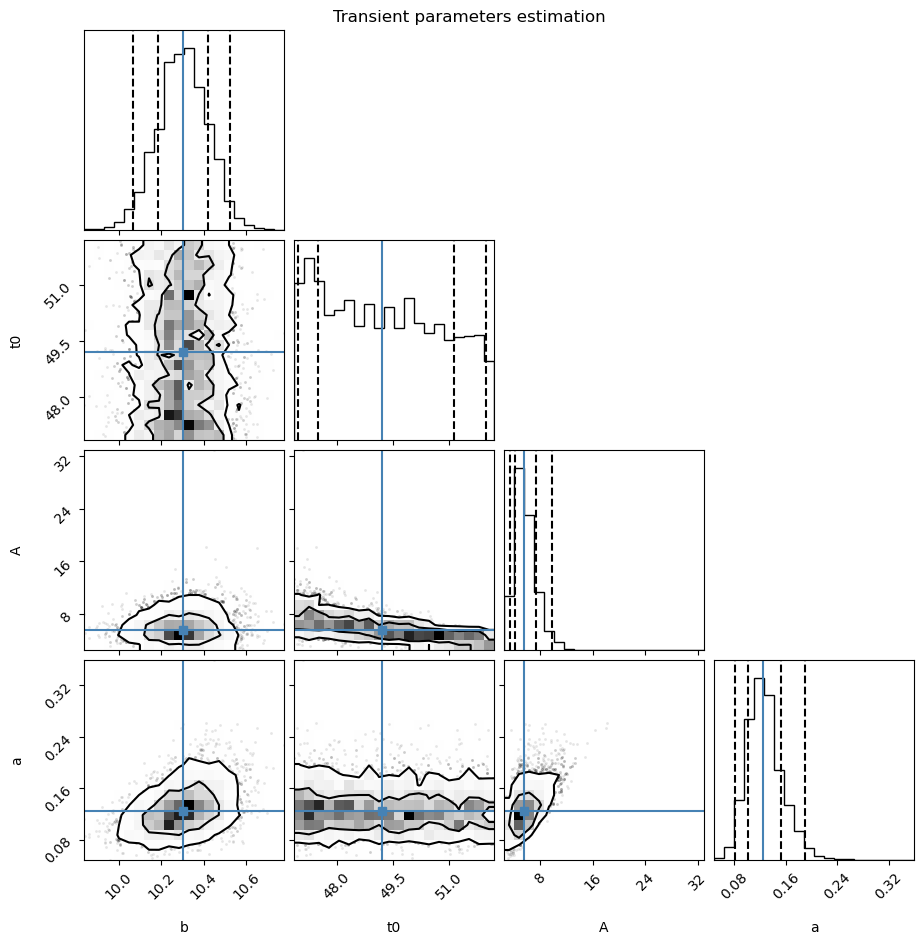

In [16]:
labels = ["b","t0","A","a"]
fig = corner.corner(samples_equal, labels=labels, quantiles=(0.025, 0.16, 0.84, 0.975), levels=(0.68, 0.95), truths=medians)
fig.suptitle("Transient parameters estimation")
plt.show()

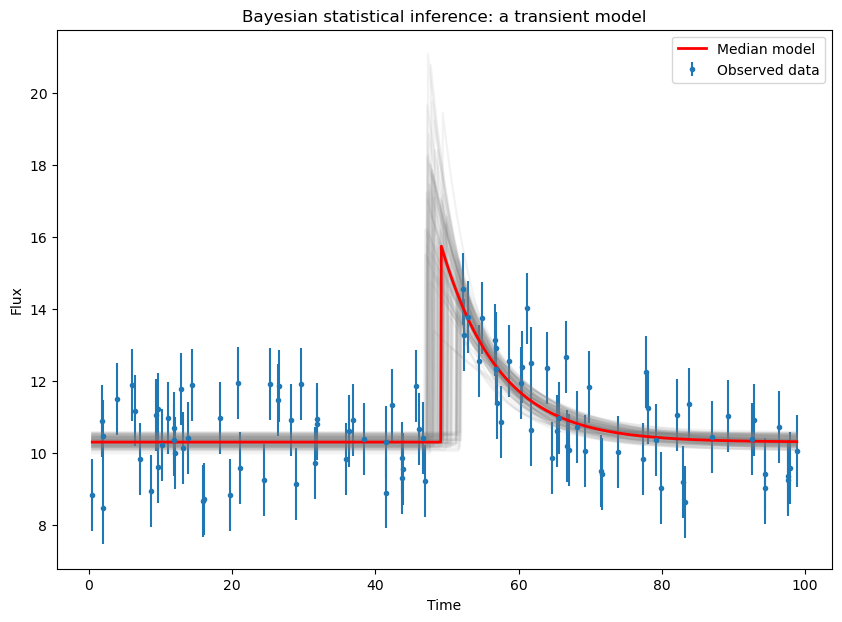

In [17]:
x_fit = np.linspace(min(time), max(time), 1000)
y_median = model(x_fit, medians)

plt.figure(figsize=(10, 7))
# Plot the observed data
plt.errorbar(time, flux, yerr=flux_err, fmt='.', label="Observed data")
# Plot a few random samples from posterior
for s in samples_equal[np.random.choice(len(samples_equal), size=100, replace=False)]:
  plt.plot(x_fit, model(x_fit, s), color='gray', alpha=0.1)
# Plot the median model
plt.plot(x_fit, y_median, lw=2, color="red", label="Median model")
plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("Bayesian statistical inference: a transient model")
plt.legend()
plt.show()

In [18]:
# pars = [b, t0, A, sigma] correct order
def model_gauss(data, pars):
    return pars[0]+pars[2]*np.exp((-1*(data-pars[1])**2)/(2*pars[3]**2))

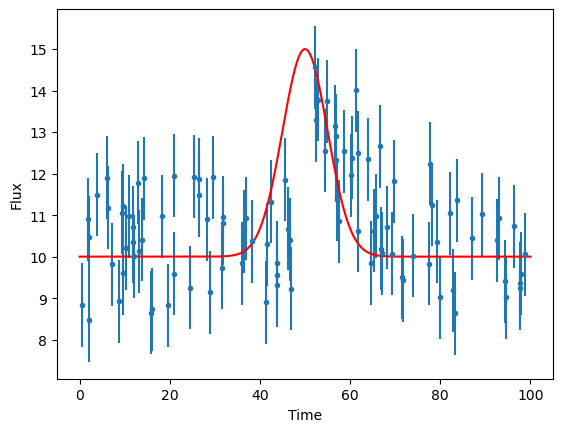

In [19]:
# calculation by hand of initial guesses
asse_x = np.linspace(0, 100, 1000)
asse_y = model_gauss(asse_x, [10, 50, 5, 5])
plt.errorbar(time, flux, yerr=flux_err, linestyle="", marker=".")
plt.plot(asse_x, asse_y, color="red")
plt.xlabel("Time")
plt.ylabel("Flux")
plt.show()

In [20]:
# let's assume gaussian homoscedastic errors
def new_logLikelihood(pars, x, y, yerr):
    y_model = model_gauss(x, pars)
    if np.any(np.isnan(y_model)) or np.any(~np.isfinite(y_model)):
      return -np.inf
    else:
      return -0.5 * np.sum(((y - y_model) / yerr)**2 + np.log(2 * np.pi * yerr**2))

In [21]:
# Be careful with how you transform your parameter space into a unit hypercube for the nested sampling priors
def new_prior_transform(vec_u):
    prior_b = 0.0 + 50.0 * vec_u[0]           # b ~ Uniform(0, 50)
    prior_t0 = 0.0 + 100.0 * vec_u[1]         # t0 ~ Uniform(0, 100)
    prior_A = 0.0 + 50.0 * vec_u[2]           # A ~ Uniform(0, 50)
    prior_ln_s = -10.0 + 20.0 * vec_u[3]      # ln(s) ~ Uniform(-10, 10)
    prior_s = np.exp(prior_ln_s)              # Convert from ln(s) to s
    return np.array([prior_b, prior_t0, prior_A, prior_s])

In [22]:
# "Static" nested sampling
new_sampler = dynesty.NestedSampler(new_logLikelihood, new_prior_transform, ndim=4, logl_args=(time, flux, flux_err))
new_sampler.run_nested()
new_sresults = new_sampler.results

4097it [00:26, 33.11it/s, bound: 78 | nc: 94 | ncall: 75092 | eff(%):  5.456 | loglstar:   -inf < -178.553 <    inf | logz: -184.940 +/-  0.104 | dlogz: 31.715 >  0.509]     C:\Users\HP\anaconda3\Lib\site-packages\dynesty\bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
4134it [00:28, 24.26it/s, bound: 85 | nc: 106 | ncall: 81050 | eff(%):  5.101 | loglstar:   -inf < -178.390 <    inf | logz: -184.928 +/-  0.104 | dlogz: 31.628 >  0.509]C:\Users\HP\anaconda3\Lib\site-packages\dynesty\bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uni

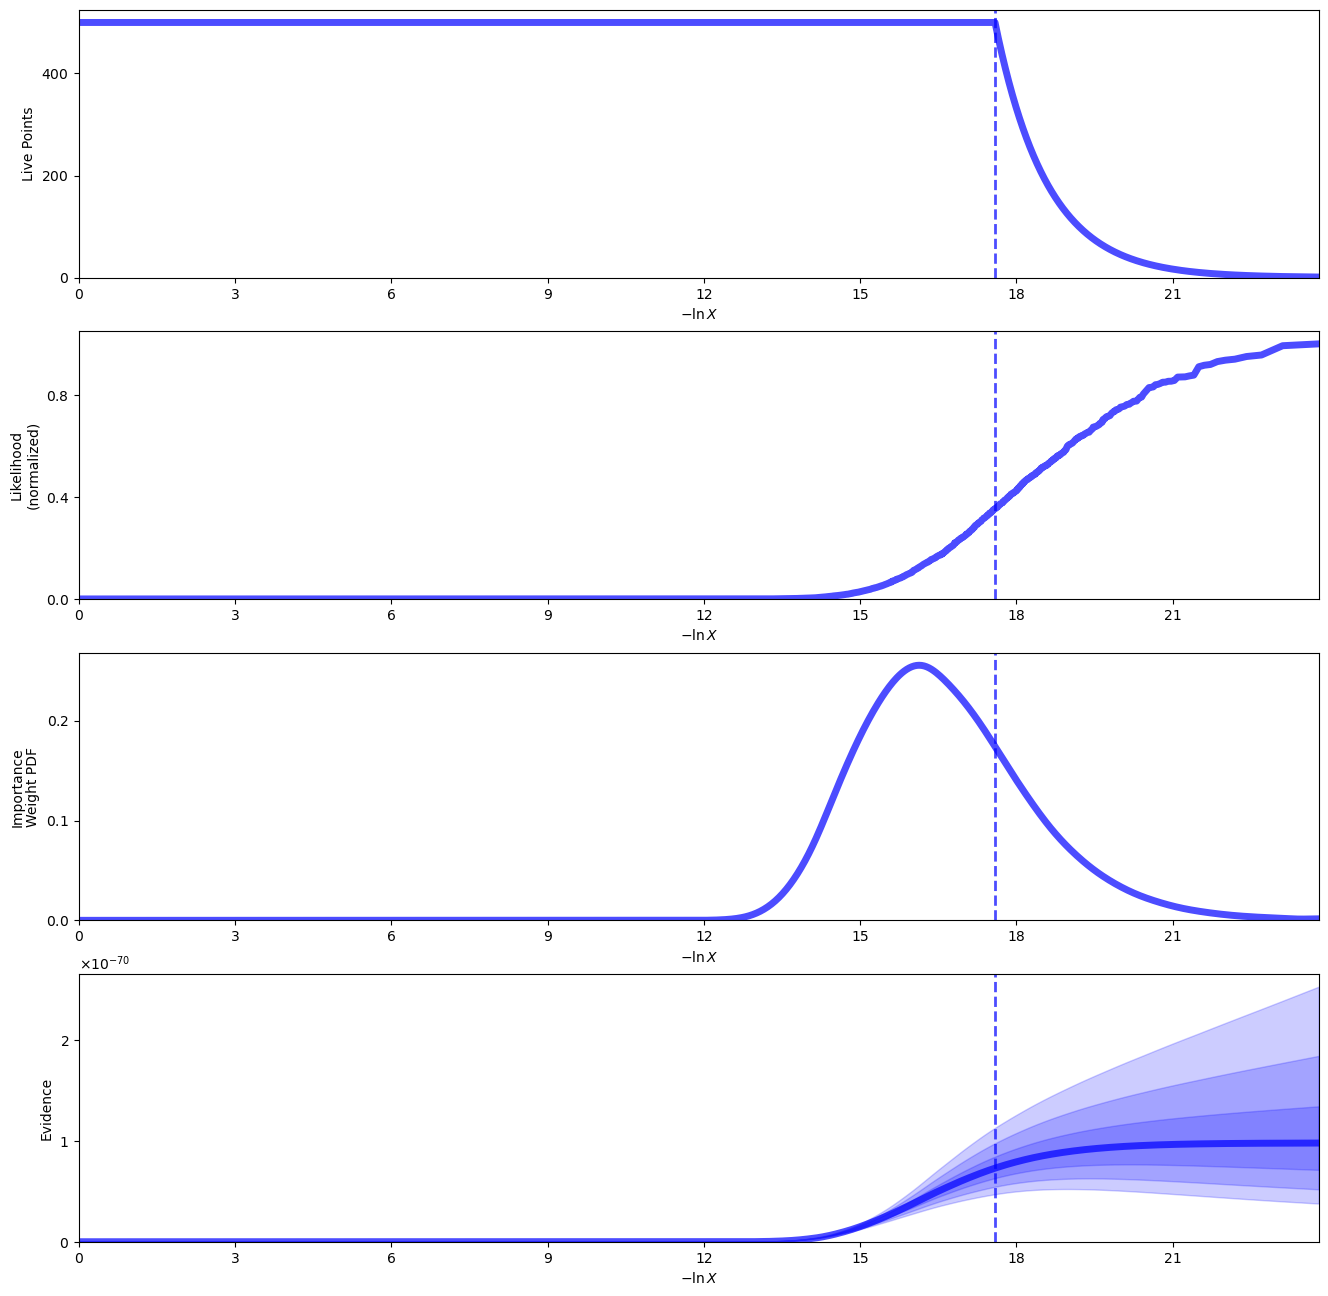

In [23]:
# Plot a summary of the run
rfig, raxes = dyplot.runplot(new_sresults)

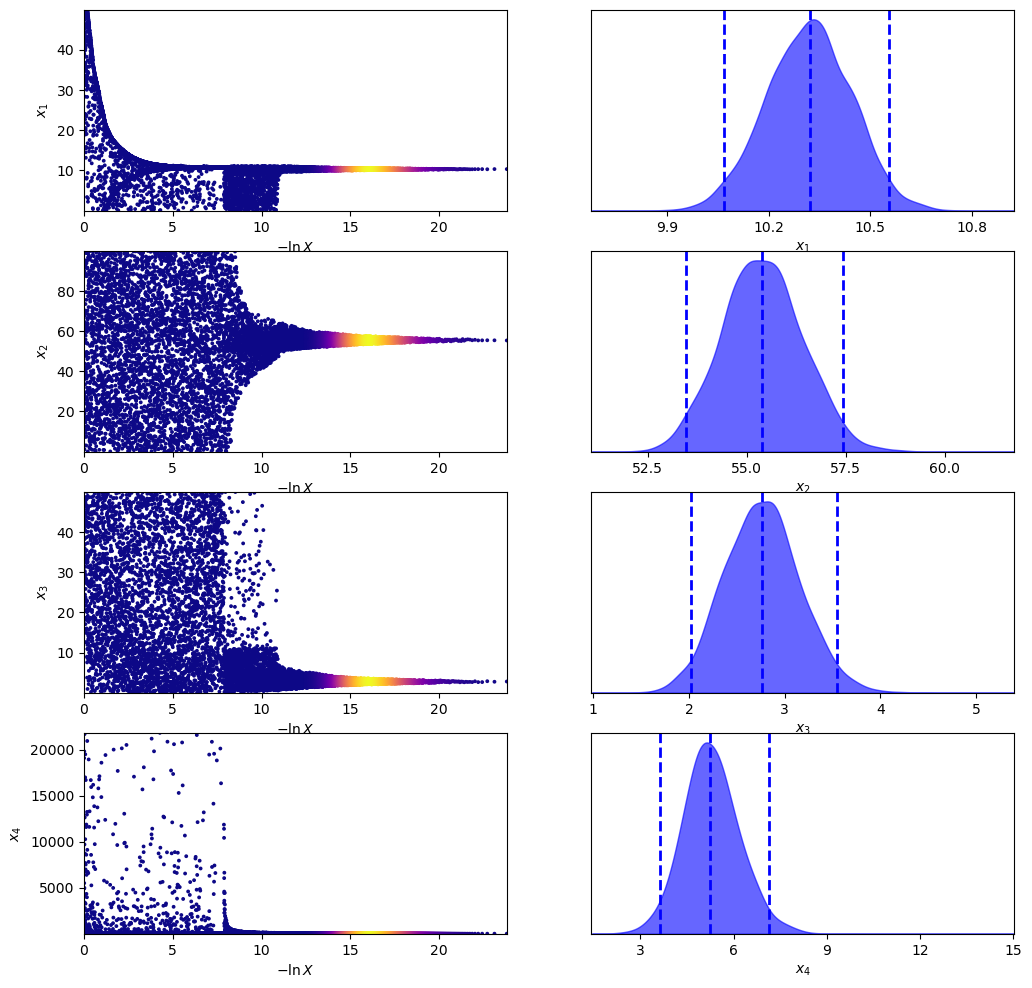

In [24]:
# Plot parameter traces and 1-D marginalized posteriors.
# On the left panels, you'll see that the live points started out scattereed across the prior volume, then move inwards as the sampler climbs the likelihood
tfig, taxes = dyplot.traceplot(new_sresults)

In [25]:
# Extract sampling results
new_samples = new_sresults.samples  # samples
new_weights = np.exp(new_sresults.logwt - new_sresults.logz[-1])  # normalized weights

new_evidence = new_sresults.logz[-1] # evidence
print(f"Bayesian evidence: {np.exp(new_evidence): .3e}")

# Compute quantiles
new_quantiles = [dyfunc.quantile(samps, [0.05, 0.16, 0.84, 0.95], weights=new_weights) for samps in new_samples.T]

# Compute medians
new_medians = [dyfunc.quantile(samps, 0.5, weights=new_weights) for samps in new_samples.T]
new_medians = np.array(new_medians).flatten()

print("ROBUST PARAMETERS ESTIMATION (using 90% parameter credible regions):")
print(f"b = {new_medians[0]: .3f} +{new_quantiles[0][3]-new_medians[0]: .3f} -{new_medians[0]-new_quantiles[0][0]: .3f}")
print(f"t0 = {new_medians[1]: .2f} +{new_quantiles[1][3]-new_medians[1]: .2f} -{new_medians[1]-new_quantiles[1][0]: .2f}")
print(f"A = {new_medians[2]: .2f} +{new_quantiles[2][3]-new_medians[2]: .2f} -{new_medians[2]-new_quantiles[2][0]: .2f}")
print(f"sigma = {new_medians[3]: .2f} +{new_quantiles[3][3]-new_medians[3]: .2f} -{new_medians[3]-new_quantiles[3][0]: .2f}")

# Compute weighted mean and covariance
new_mean, new_cov = dyfunc.mean_and_cov(new_samples, new_weights)
print("MEAN AND STD PARAMETERS ESTIMATION:")
print(f"b = {new_mean[0]: .2f} +-{np.sqrt(new_cov[0,0]): .2f}")
print(f"t0 = {new_mean[1]: .2f} +-{np.sqrt(new_cov[1,1]): .2f}")
print(f"A = {new_mean[2]: .2f} +-{np.sqrt(new_cov[2,2]): .2f}")
print(f"sigma = {new_mean[3]: .2f} +-{np.sqrt(new_cov[3,3]): .2f}")

Bayesian evidence:  9.792e-71
ROBUST PARAMETERS ESTIMATION (using 90% parameter credible regions):
b =  10.321 + 0.199 - 0.214
t0 =  55.39 + 1.70 - 1.66
A =  2.76 + 0.66 - 0.62
sigma =  5.24 + 1.56 - 1.35
MEAN AND STD PARAMETERS ESTIMATION:
b =  10.32 +- 0.12
t0 =  55.40 +- 1.01
A =  2.76 +- 0.39
sigma =  5.29 +- 0.89


In [26]:
# dynesty can postprocess results to produce equally weighted samples.
# This is useful if you then want to used them in another package (for instance corner) that cannot deal with weights.
# Resample weighted samples
new_samples_equal = dyfunc.resample_equal(new_samples, new_weights)

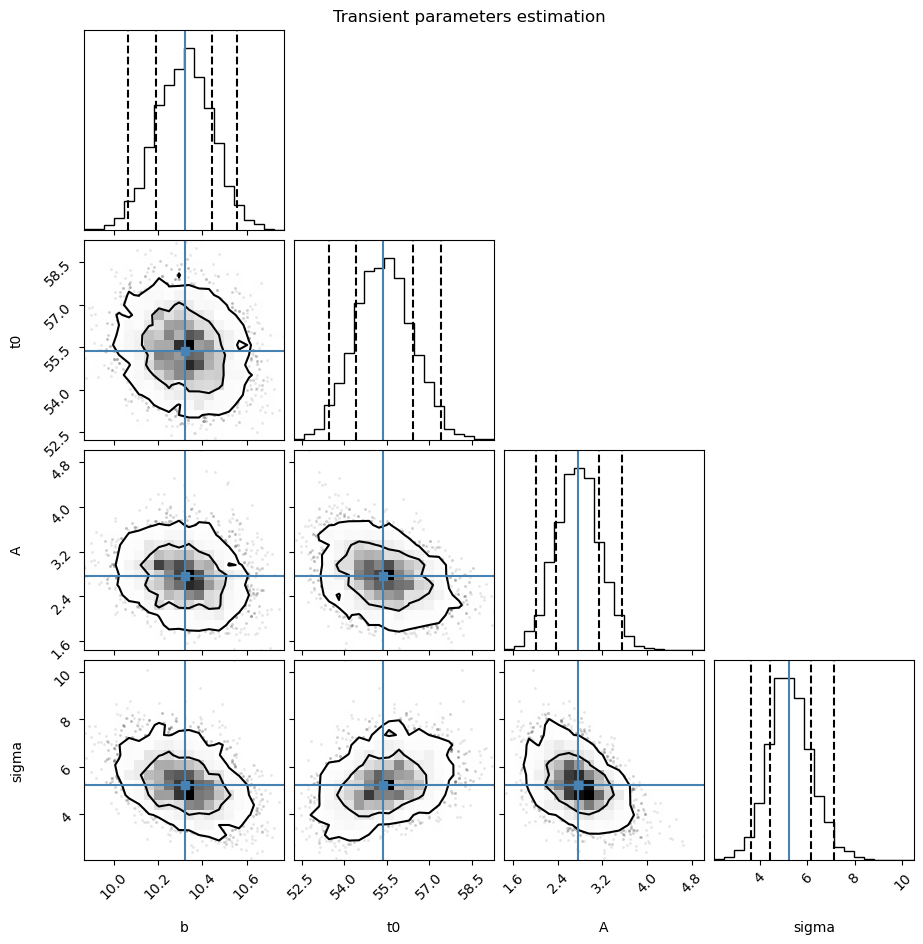

In [27]:
labels = ["b","t0","A","sigma"]
fig = corner.corner(new_samples_equal, labels=labels, quantiles=(0.025, 0.16, 0.84, 0.975), levels=(0.68, 0.95), truths=new_medians)
fig.suptitle("Transient parameters estimation")
plt.show()

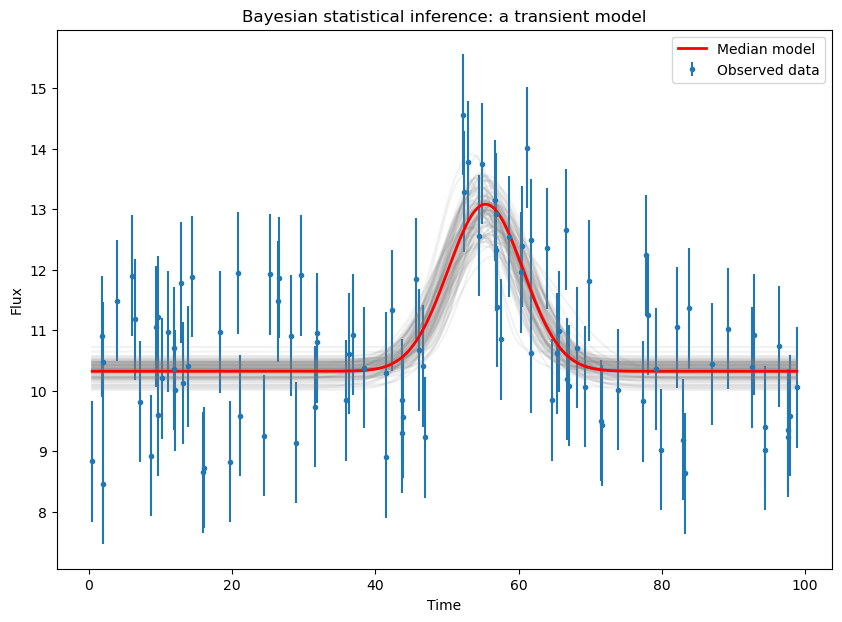

In [28]:
x_fit = np.linspace(min(time), max(time), 1000)
y_median = model_gauss(x_fit, new_medians)

plt.figure(figsize=(10, 7))
# Plot the observed data
plt.errorbar(time, flux, yerr=flux_err, fmt='.', label="Observed data")
# Plot a few random samples from posterior
for s in new_samples_equal[np.random.choice(len(new_samples_equal), size=100, replace=False)]:
  plt.plot(x_fit, model_gauss(x_fit, s), color='gray', alpha=0.1)
# Plot the median model
plt.plot(x_fit, y_median, lw=2, color="red", label="Median model")
plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("Bayesian statistical inference: a transient model")
plt.legend()
plt.show()

In [29]:
# Use Jeffreys scale
bayes_factor = np.exp(evidence - new_evidence)
print(f"Bayes factor: {bayes_factor: .0f}")
print("Jeffreys interpretation:")
if(bayes_factor<1):
  print("The burst model is not preferred (the gaussian model is supported)")
if(bayes_factor>=1 and bayes_factor<3):
  print("The burst model is barely preferred")
if(bayes_factor>=3 and bayes_factor<10):
  print("The burst model is substantially preferred")
if(bayes_factor>=10 and bayes_factor<30):
  print("The burst model is strongly preferred")
if(bayes_factor>=30 and bayes_factor<100):
  print("The burst model is very strongly preferred")
if(bayes_factor>=100):
  print("The burst model is decisively preferred")

Bayes factor:  426
Jeffreys interpretation:
The burst model is decisively preferred


## Nested sampling
Nested sampling is a very different MCMC method from Metropolis-Hastings or even Gibbs approaches.
It is based on a numerical integrator in order to sample both posterior and evidence. The latter is required to do model selection through the application of Odds ratio and Bayes factor.

## Important things:
1. Samples that come out of nested sampling runs are weighted. The results of nested sampling are the samples and their weights together. Do not use samples by themselves, it doesn't make sense.

2. If an MCMC is taking too long, you can interrupt it and use samples you got so far (assuming you're past the burn in period). This is not possible with nested sampling: samples don't make any sense untill the algorithm reached the top of the posterior! You have to let it go till the end.